# IF01 — Demo de Preparación de Datos

**Dataset:** `00_demo_insurance.csv` · **Variable objetivo:** `charges` → regresión

---

### Enunciado del caso

Una aseguradora médica tiene los datos históricos de 20,300 clientes (edad, IMC, condición de fumador, hijos, región, ingresos) y el costo anual que cada uno terminó pagando por su seguro. Hoy las primas se calculan con tablas heurísticas, lo que produce estimaciones imprecisas: en algunos casos se cobra de más y la aseguradora pierde competitividad, y en otros se cobra de menos y la empresa pierde dinero.

### Objetivo del negocio

Construir un modelo predictivo que estime el **costo anual del seguro** (`charges`) para un cliente nuevo en función de sus características personales, y así calcular primas justas, reducir pérdidas y entender qué factores encarecen el seguro.

### Objetivo de los pasos (este notebook)

Antes de entrenar el modelo, hay que dejar el dataset **limpio, completo y en formato 100% numérico**. Los 11 pasos resuelven los problemas típicos de calidad de datos (nulos, duplicados, columnas irrelevantes, tipos incorrectos, outliers) y transforman las variables de texto a 0/1 para que cualquier algoritmo de regresión pueda procesarlas en la Semana 2.

## Paso 0: Importar librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---

# Bloque A — Conocer los datos

Cargamos el archivo y entendemos su estructura antes de tocar nada.

## Paso 1: Cargar el CSV

Subimos el archivo a Colab y lo leemos como DataFrame.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving 00_demo_insurance.csv to 00_demo_insurance.csv


In [ ]:
df = pd.read_csv("00_demo_insurance.csv", encoding="latin1")
df.head()

,customer_id,full_name,registration_date,age,sex,bmi,children,smoker,region,annual_income,charges
0,CUST-002826,Cliente 2826,2020-11-22,36.0,male,37.89,2,yes,northeast,46029.67,38678.67
1,CUST-005601,Cliente 5601,2022-03-02,42.0,male,40.40,5,yes,southeast,NaN,34680.34
2,CUST-007888,Cliente 7888,2024-09-05,35.0,male,33.25,3,no,southwest,39179.98,8665.17
3,CUST-009109,Cliente 9109,2020-07-21,22.0,female,15.53,1,no,southwest,NaN,9909.89
4,CUST-007677,Cliente 7677,2020-05-14,51.0,female,21.46,4,no,southeast,NaN,19475.63


→ Vemos las primeras 5 filas para confirmar que la carga fue correcta.

## Paso 2: Explorar la estructura

Tres funciones nos dan una radiografía rápida del dataset.

In [ ]:
df.shape

(20300, 11)

→ `(filas, columnas)`. Confirmamos el tamaño del dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20300 entries, 0 to 20299
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        20300 non-null  object 
 1   full_name          20300 non-null  object 
 2   registration_date  20300 non-null  object 
 3   age                19078 non-null  float64
 4   sex                20300 non-null  object 
 5   bmi                19285 non-null  float64
 6   children           20300 non-null  int64  
 7   smoker             20300 non-null  object 
 8   region             19691 non-null  object 
 9   annual_income      18874 non-null  float64
 10  charges            20300 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.7+ MB


→ Tipos de datos y conteo de no-nulos por columna. Aquí detectamos qué columnas tienen nulos.

In [ ]:
df.describe()

,age,bmi,children,annual_income,charges
count,19078.000000,19285.000000,20300.000000,18874.000000,20300.000000
mean,41.015358,29.961173,2.525271,40986.507782,18878.301150
std,13.605720,5.944761,1.719964,21791.117917,9891.629209
min,18.000000,15.000000,0.000000,10000.000000,800.000000
25%,29.000000,25.950000,1.000000,25847.950000,12087.915000
50%,41.000000,29.890000,3.000000,36186.380000,15953.715000
75%,53.000000,33.920000,4.000000,50608.312500,21198.905000
max,64.000000,55.000000,5.000000,254557.900000,87367.390000


→ Estadísticas (media, mín, máx, cuartiles) de las numéricas. Si `mean` y la mediana (`50%`) son muy distintos, hay asimetría.

### Identificar el rol de cada columna

| Columna | Tipo | Rol | Por qué |
|---|---|---|---|
| `customer_id` | texto | Irrelevante | Identificador único, distinto en cada fila |
| `full_name` | texto | Irrelevante | Nombre del cliente, no influye en el costo |
| `registration_date` | fecha | Irrelevante | Fecha administrativa, no afecta el costo |
| `age` | numérica | Predictora (X) | A mayor edad, más gastos médicos esperados |
| `sex` | categórica | Predictora (X) | Hay diferencias estadísticas en costos por sexo |
| `bmi` | numérica | Predictora (X) | Un IMC alto se asocia con más enfermedades |
| `children` | numérica | Predictora (X) | Más dependientes amplían la cobertura |
| `smoker` | categórica | Predictora (X) | Fumar incrementa fuertemente el costo del seguro |
| `region` | categórica | Predictora (X) | Los costos médicos varían por zona geográfica |
| `annual_income` | numérica | Predictora (X) | Puede correlacionar con el plan contratado |
| **`charges`** | **numérica** | **Objetivo (y)** | **Es lo que la aseguradora quiere predecir** |

---

# Bloque B — Limpiar

Tratamos los problemas de calidad: nulos, duplicados, columnas que no aportan, tipos incorrectos y outliers.

## Paso 3: Detectar valores faltantes (nulos)

Los nulos son celdas vacías. **Imputar** = rellenar el hueco con un valor representativo.

In [ ]:
df.isnull().sum()

,0
customer_id,0
full_name,0
registration_date,0
age,1222
sex,0
bmi,1015
children,0
smoker,0
region,609
annual_income,1426


→ Cantidad de nulos por columna.

Para imputar usamos:
- Numérica → la **mediana** (resiste outliers).
- Categórica → la **moda** (valor más frecuente).

In [ ]:
df['age'] = df['age'].fillna(df['age'].median())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].median())
df['region'] = df['region'].fillna(df['region'].mode()[0])

df.isnull().sum()

,0
customer_id,0
full_name,0
registration_date,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
annual_income,0


→ Ya no hay nulos en ninguna columna.

## Paso 4: Eliminar duplicados

Filas idénticas sesgan el modelo. Las eliminamos.

In [ ]:
print("Duplicados:", df.duplicated().sum())
df = df.drop_duplicates()
print("Tamaño después:", df.shape)

Duplicados: 300
Tamaño después: (20000, 11)


→ Vemos cuántos duplicados había y el tamaño final del dataset.

## Paso 5: Quitar columnas irrelevantes

Eliminamos las columnas que en el Paso 2 marcamos como irrelevantes: `customer_id` y `full_name`. La fecha la tratamos en el Paso 6.

In [ ]:
df = df.drop(columns=['customer_id', 'full_name'])
df.columns

Index(['registration_date', 'age', 'sex', 'bmi', 'children', 'smoker',
       'region', 'annual_income', 'charges'],
      dtype='object')

→ Quedaron 9 columnas.

## Paso 6: Verificar tipos de datos

Cada columna debe tener el tipo correcto.

In [ ]:
df.dtypes

,0
registration_date,object
age,float64
sex,object
bmi,float64
children,int64
smoker,object
region,object
annual_income,float64
charges,float64


→ `registration_date` está como `object` (texto) cuando debería ser fecha.

In [ ]:
df['registration_date'] = pd.to_datetime(df['registration_date'])

# La fecha de registro no influye en el costo → la eliminamos
df = df.drop(columns=['registration_date'])
df.dtypes

,0
age,float64
sex,object
bmi,float64
children,int64
smoker,object
region,object
annual_income,float64
charges,float64


→ Tipos correctos. Quedan numéricas y categóricas listas para el siguiente bloque.

## Paso 7: Detectar outliers en `charges` (costo del seguro)

Un **outlier** es un valor que se aleja mucho del resto. Lo detectamos con la regla del IQR:

```
Q1 = percentil 25,  Q3 = percentil 75,  IQR = Q3 - Q1
Outlier si:  valor > Q3 + 1.5·IQR   ó   valor < Q1 - 1.5·IQR
```

**Cómo leer el boxplot:**
- La **caja** contiene el 50% central (de Q1 a Q3); la línea dentro es la mediana.
- Los **bigotes** llegan al último valor dentro del rango normal.
- Los **puntos sueltos** afuera son outliers.

Comparando las dos cajas: la de **fumadores** está mucho más arriba que la de no fumadores, y los puntos extremos están casi todos en ese grupo. → Los costos altos están explicados por fumar, no son errores.

In [ ]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

outliers = df[df['charges'] > limite_sup]
print(f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

Outliers: 2562 (12.8%)


→ Hay outliers. Para saber si son reales o errores, agrupamos por `smoker` porque fumar es el factor con mayor impacto conocido en el costo de un seguro médico.

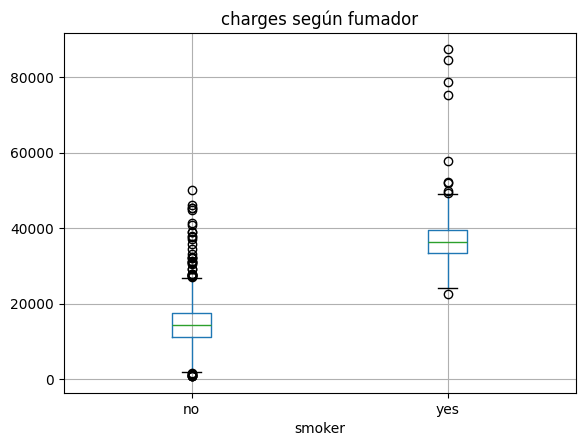

In [ ]:
df.boxplot(column='charges', by='smoker')
plt.suptitle("")
plt.title("charges según fumador")
plt.show()

→ Los costos altos están concentrados en **fumadores** → son casos reales, **los mantenemos**.

---

# Bloque C — Transformar

Ponemos los datos en formato 100% numérico para que el modelo pueda procesarlos.

## Paso 8: Separar numéricas y categóricas

Necesario porque el One-Hot Encoding solo se aplica a categóricas.

In [ ]:
numericas = df.select_dtypes(include='number').columns.tolist()
categoricas = df.select_dtypes(include='object').columns.tolist()

print("Numéricas:", numericas)
print("Categóricas:", categoricas)

Numéricas: ['age', 'bmi', 'children', 'annual_income', 'charges']
Categóricas: ['sex', 'smoker', 'region']


→ `sex`, `smoker`, `region` son las que vamos a transformar.

## Paso 9: One-Hot Encoding

Convierte cada categoría en una columna binaria (0/1) para que el modelo la pueda procesar.

| smoker (antes) | smoker_yes (después) |
|---|---|
| yes | 1 |
| no | 0 |

`drop_first=True` elimina una columna por variable para evitar redundancia.

In [ ]:
df_encoded = pd.get_dummies(df, columns=categoricas, drop_first=True)
df_encoded.head()

,age,bmi,children,annual_income,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,36.0,37.89,2,46029.67,38678.67,True,True,False,False,False
1,42.0,40.40,5,36186.38,34680.34,True,True,False,True,False
2,35.0,33.25,3,39179.98,8665.17,True,False,False,False,True
3,22.0,15.53,1,36186.38,9909.89,False,False,False,False,True
4,51.0,21.46,4,36186.38,19475.63,False,False,False,True,False


→ Las columnas de texto se reemplazaron por columnas con valores 0 y 1.

---

# Bloque D — Validar y guardar

Revisamos que la variable objetivo tiene sentido y guardamos el dataset listo para Semana 2.

## Paso 10: Visualizar la variable objetivo

Un histograma de `charges` nos muestra cómo se distribuye el costo del seguro.

**Cómo leer el histograma:**
- Eje X: rango de valores de `charges` (USD).
- Eje Y (frecuencia): cuántos clientes caen en cada rango.
- Si una barra tiene altura 800, significa que 800 clientes pagan un costo dentro de ese rango.

**Forma de la distribución:**

```
    Simétrica                Asimétrica con cola a la derecha
   (tipo campana)              (es la que vemos aquí)

         ▌                              ▌
        ▌▌▌                            ▌▌
       ▌▌▌▌▌                           ▌▌▌
      ▌▌▌▌▌▌▌                          ▌▌▌▌
     ▌▌▌▌▌▌▌▌▌                         ▌▌▌▌▌▁▁▁▁
                                              ↑
                                            cola
```

- **Asimétrica** → un lado es distinto del otro (no se refleja como espejo).
- **Cola a la derecha** → barras pequeñas que se extienden hacia los valores altos (no son barras altas, son barras bajas pero alargadas).

**Lectura del caso:** la mayoría de clientes paga costos bajos-medios (barras altas a la izquierda) y unos pocos pagan costos muy altos (cola hacia la derecha).

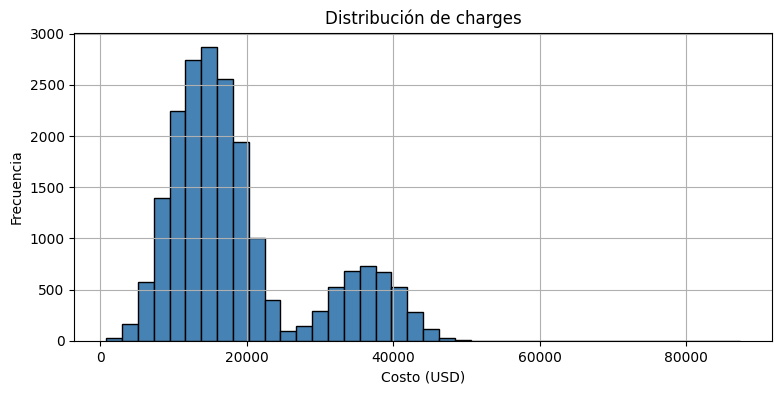

In [ ]:
plt.figure(figsize=(9, 4))
df_encoded['charges'].hist(bins=40, color='steelblue', edgecolor='black')
plt.title("Distribución de charges")
plt.xlabel("Costo (USD)")
plt.ylabel("Frecuencia")
plt.show()

→ La distribución es **asimétrica con cola a la derecha**: la mayoría paga costos bajos y unos pocos pagan mucho.

## Paso 11: Guardar el dataset preparado

In [ ]:
df_encoded.to_csv("insurance_preparado.csv", index=False)
print("Guardado. Tamaño:", df_encoded.shape)

Guardado. Tamaño: (20000, 10)


In [ ]:
# (Opcional) descargar el archivo
from google.colab import files
files.download("insurance_preparado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## Cierre

| Bloque | Resultado |
|---|---|
| A. Conocer | Variable objetivo identificada (`charges`) |
| B. Limpiar | Nulos imputados, duplicados eliminados, irrelevantes quitadas, outliers conservados |
| C. Transformar | Categóricas convertidas a 0/1 |
| D. Validar y guardar | Distribución verificada, dataset exportado |

**Próxima sesión:** entrenar modelos de regresión sobre `insurance_preparado.csv`.